<a href="https://colab.research.google.com/github/Davide537/Internship-code/blob/main/ML_project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1

In [ ]:
import numpy as np


class FeedforwardNeuralNetwork:
    def __init__(self, layer_sizes):
        """
        Initialize the feedforward neural network.

        Parameters:
        layer_sizes (list): List containing the number of neurons in each layer.
        """
        self.layer_sizes = layer_sizes
        self.num_layers = len(layer_sizes)
        self.weights = []
        self.biases = []

        # Insert missing code!
        #i think we are meant to itialize the weights and biases of the network randomly here
        for i in range(self.num_layers - 1):
            self.weights.append(np.random.randn(layer_sizes[i+1], layer_sizes[i]) * 0.01)
            self.biases.append(np.random.randn(layer_sizes[i+1], 1))

    def activation_relu(self, z):
        """
        ReLU activation function.
        """
        return np.maximum(0, z)

    def activation_sigmoid(self, z):
        """
        Sigmoid activation function.
        """
        return 1 / (1 + np.exp(-z))

    def activation_derivative_relu(self, z):
        """
        Derivative of ReLU activation function.
        """
        return (z > 0).astype(float)

    def activation_derivative_sigmoid(self, z):
        """
        Derivative of Sigmoid activation function.
        """
        sigmoid = self.activation_sigmoid(z)
        return sigmoid * (1 - sigmoid)


    def feedforward(self, x, input="sigmoid"):
        """
        Perform a feedforward pass through the network.
        """
        activations = [x]
        zs = []

        for w, b in zip(self.weights, self.biases):
            z = np.dot(w, activations[-1]) + b
            zs.append(z)
            if input=="sigmoid":
                activation = self.activation_sigmoid(z)
            else:
                activation = self.activation_relu(z)
            activations.append(activation)

        return activations, zs

    def compute_cost(self, y_pred, y_train):
        """
        Compute the cost function using Mean Squared Error (MSE).
        """
        n = y_train.shape[1]
        return np.sum((np.linalg.norm(y_pred - y_train))**2) / n


    def backpropagate(self, x, y_train, input="sigmoid"):
        """
        Perform backpropagation to compute gradients.
        """
        # Forward pass
        activations, zs = self.feedforward(x, input)
        y_pred = activations[-1]
        n = y_train.shape[1]
        error = y_pred - y_train

        # Gradients for the output layer
        nabla_w = []
        nabla_b = []
        if input=="sigmoid":
            delta = error * self.activation_derivative_sigmoid(zs[-1])
        else:
            delta = error * self.activation_derivative_relu(zs[-1])
        nabla_w.append(np.dot(delta, activations[-2].T) / n)
        nabla_b.append(np.sum(delta, axis=1, keepdims=True) / n)

        # Backpropagate through hidden layers
        for l in range(2, self.num_layers):
            z = zs[-l]
            if input=="sigmoid":
                delta = np.dot(self.weights[-l+1].T, delta) * self.activation_derivative_sigmoid(z)
            else:
                delta = np.dot(self.weights[-l+1].T, delta) * self.activation_derivative_relu(z)

            nabla_w.insert(0, np.dot(delta, activations[-l-1].T) / n)
            nabla_b.insert(0, np.sum(delta, axis=1, keepdims=True) / n)

        return nabla_w, nabla_b


    def update_parameters(self, nabla_w, nabla_b, learning_rate):
        """
        Update the weights and biases using the computed gradients.
        """
        for i in range(len(self.weights)):
            self.weights[i] -= learning_rate * nabla_w[i]
            self.biases[i] -= learning_rate * nabla_b[i]

    def train(self, x_train, y_train, epochs, learning_rate, batch_size , input="sigmoid"):
        """
        Train the neural network using mini-batch gradient descent.
        """
        m = x_train.shape[1]

        for epoch in range(epochs):
            # Shuffle the data
            perm = np.random.permutation(m)
            x_train_shuffled = x_train[:, perm]
            y_train_shuffled = y_train[:, perm]

            for i in range(0, m, batch_size):
                x_batch = x_train_shuffled[:, i:i+batch_size]
                y_batch = y_train_shuffled[:, i:i+batch_size]

                # Compute gradients
                nabla_w, nabla_b = self.backpropagate(x_batch, y_batch,input)

                # Update parameters
                self.update_parameters(nabla_w, nabla_b, learning_rate)

            # Compute and print the loss every epoch
            activations, _ = self.feedforward(x_train,input)
            y_pred = activations[-1]
            cost = self.compute_cost(y_pred, y_train)
            # print(f"Epoch {epoch + 1}/{epochs}, Loss: {cost:.4f}")
            # print(f"Epoch {epoch + 1}/{epochs}, Loss: {cost}")




In [ ]:
# Generate training data
import numpy as np

# Define the domain
n_points = 1000  # Number of training points
x = np.linspace(0, 1, int(np.sqrt(n_points)))
y = np.linspace(0, 1, int(np.sqrt(n_points)))
xx, yy = np.meshgrid(x, y)
points = np.column_stack([xx.ravel(), yy.ravel()])  # Points in Ω



# Compute the exact solution
u_exact = np.sin( np.pi * points[:, 0]) * np.sin( np.pi * points[:, 1])  # Analytical solution

x_train = points.T  # Shape: (2, n_points)
y_train = u_exact.reshape(1, -1)  # Shape: (1, n_points)

epochs = 5000
learning_rate = 0.01
batch_size = 32
layer_sizes = [2, 20, 20, 1]

nn = FeedforwardNeuralNetwork(layer_sizes)
nn.train(x_train, y_train, epochs, learning_rate, batch_size, "sigmoid")



In [ ]:
# Test data (same as training for visualization)
x_test = x_train
activations, _ = nn.feedforward(x_test, input="sigmoid")  # Use sigmoid activation
y_pred = activations[-1]

# Compute and print mean squared error
mse = nn.compute_cost(y_pred, y_train)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 0.09059247791906816


In [ ]:
### cross validation and grid search
from sklearn.model_selection import KFold

def cross_validate(nn, x_train, y_train, learning_rate=0.01 , n_splits=5, input="sigmoid"):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    mse_scores = []
    for train_index, val_index in kf.split(x_train.T):
        x_train_fold, x_val_fold = x_train[:, train_index], x_train[:, val_index]
        y_train_fold, y_val_fold = y_train[:, train_index], y_train[:, val_index]

        nn.train(x_train_fold, y_train_fold, epochs=500, learning_rate=0.01, batch_size=32, input="sigmoid")
        activations, _ = nn.feedforward(x_val_fold, input="sigmoid")
        y_pred = activations[-1]
        mse =np.mean((y_val_fold.T - y_pred.T)**2)
        mse_scores.append(mse)

    return np.mean(mse_scores)


def grid_search(x_train, y_train):
    architectures = [[2, 20, 20, 1], [2, 50, 50, 1], [2, 10, 10, 10, 1]]
    activation_functions = ["sigmoid", "relu"]
    learning_rates = [1e-4, 1e-3, 1e-2]

    best_mse = float('inf')
    best_params = None

    for architecture in architectures:
        for activation in activation_functions:
            for lr in learning_rates:
                print(f"Training with architecture {architecture}, activation {activation}, and learning rate {lr}")

                nn = FeedforwardNeuralNetwork(architecture)
                mse = cross_validate(nn, x_train, y_train, lr, n_splits=5 , input=activation)

                if mse < best_mse:
                    best_mse = mse
                    best_params = (architecture, activation, lr)

                # print(f"Validation MSE: {mse:.4f}")
                print(f"Validation MSE: {mse}")

    # print(f"Best Hyperparameters: {best_params} with MSE: {best_mse:.4f}")
    print(f"Best Hyperparameters: {best_params} with MSE: {best_mse}")
    return best_params

best_params = grid_search(x_train, y_train)

Training with architecture [2, 20, 20, 1], activation sigmoid, and learning rate 0.0001
Validation MSE: 0.09073837965402513
Training with architecture [2, 20, 20, 1], activation sigmoid, and learning rate 0.001
Validation MSE: 0.0907117871035571
Training with architecture [2, 20, 20, 1], activation sigmoid, and learning rate 0.01
Validation MSE: 0.09069275536430779
Training with architecture [2, 20, 20, 1], activation relu, and learning rate 0.0001
Validation MSE: 0.0907217166895042
Training with architecture [2, 20, 20, 1], activation relu, and learning rate 0.001
Validation MSE: 0.0906554752319452
Training with architecture [2, 20, 20, 1], activation relu, and learning rate 0.01
Validation MSE: 0.0906910748344184
Training with architecture [2, 50, 50, 1], activation sigmoid, and learning rate 0.0001
Validation MSE: 0.09069442618665932
Training with architecture [2, 50, 50, 1], activation sigmoid, and learning rate 0.001
Validation MSE: 0.09068585124694403
Training with architecture [

## POISSON  SOLVER

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

class PoissonSolver2D:
    def __init__(self, nx, ny, lx, ly):
        """
        Initialize the Poisson solver with grid size and domain dimensions.

        Parameters:
        nx (int): Number of grid points in the x-direction.
        ny (int): Number of grid points in the y-direction.
        lx (float): Length of the domain in the x-direction.
        ly (float): Length of the domain in the y-direction.
        """
        self.nx = nx
        self.ny = ny
        self.lx = lx
        self.ly = ly
        self.dx = lx / (nx - 1)
        self.dy = ly / (ny - 1)
        self.u = np.zeros((ny, nx))  # Solution array
        self.f = np.zeros((ny, nx))  # Source term array

    def set_boundary_conditions(self, boundary_func):
        """
        Set the boundary conditions using a provided function.

        Parameters:
        boundary_func (function): Function that takes (x, y) and returns the boundary value.
        """
        for i in range(self.nx):
            self.u[0, i] = boundary_func(i * self.dx, 0)  # Bottom boundary
            self.u[-1, i] = boundary_func(i * self.dx, self.ly)  # Top boundary
        for j in range(self.ny):
            self.u[j, 0] = boundary_func(0, j * self.dy)  # Left boundary
            self.u[j, -1] = boundary_func(self.lx, j * self.dy)  # Right boundary

    def set_source_term(self, source_func):
        """
        Set the source term using a provided function.

        Parameters:
        source_func (function): Function that takes (x, y) and returns the source term value.
        """
        for j in range(1, self.ny - 1):
            for i in range(1, self.nx - 1):
                self.f[j, i] = source_func(i * self.dx, j * self.dy)

    def setup_linear_system(self):
        """
        Set up the linear system for the Poisson equation.

        Returns:
        A (scipy.sparse.lil_matrix): Sparse matrix representing the linear system.
        b (numpy.ndarray): Right-hand side vector.
        """
        n = self.nx * self.ny
        A = lil_matrix((n, n))
        b = np.zeros(n)

        for j in range(self.ny):
            for i in range(self.nx):
                idx = j * self.nx + i
                if i == 0 or i == self.nx - 1 or j == 0 or j == self.ny - 1:
                    A[idx, idx] = 1
                    b[idx] = self.u[j, i]
                else:
                    A[idx, idx] = -4
                    A[idx, idx - 1] = 1
                    A[idx, idx + 1] = 1
                    A[idx, idx - self.nx] = 1
                    A[idx, idx + self.nx] = 1
                    b[idx] = - (self.dx*self.dy) * self.f[j, i]

        return A, b

    def solve(self):
        """
        Solve the Poisson equation using a sparse direct solver.
        """
        A, b = self.setup_linear_system()
        u_flat = spsolve(A.tocsr(), b)
        self.u = u_flat.reshape((self.ny, self.nx))

    def get_solution(self):
        """
        Get the solution of the Poisson equation.

        Returns:
        numpy.ndarray: Solution array.
        """
        return self.u

    def get_meshgrid(self):
        """
        Get the meshgrid for the domain.

        Returns:
        numpy.ndarray: Meshgrid for the domain.
        """
        x = np.linspace(0, self.lx, self.nx)
        y = np.linspace(0, self.ly, self.ny)
        return np.meshgrid(x, y)

    def plot_solution(self):
        """
        Plot the solution of the Poisson equation.
        """
        plt.imshow(self.u, origin='lower', extent=(0, self.lx, 0, self.ly))
        plt.colorbar()
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('Poisson equation solution')
        plt.show()

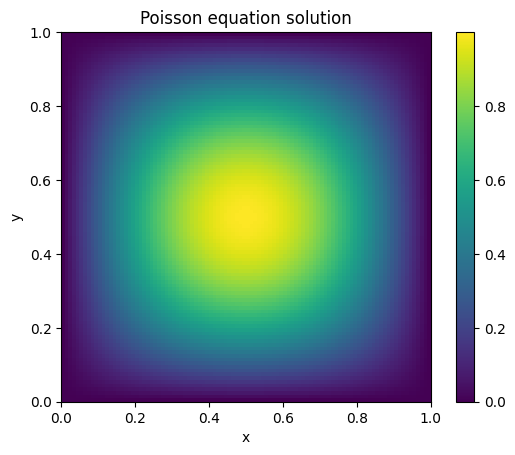

In [ ]:
# Define the boundary condition function
def boundary_func(x, y):
    return 0.0

# Define the source term function
def source_func(x, y):
    return 2.0 * np.pi**2 * np.sin(np.pi * x) * np.sin(np.pi * y)

# Create an instance of the PoissonSolver2D class
solver = PoissonSolver2D(nx=100, ny=100, lx=1.0, ly=1.0)

# Set the boundary conditions
solver.set_boundary_conditions(boundary_func)

# Set the source term
solver.set_source_term(source_func)

# Setup the linear system
solver.setup_linear_system()

# Solve the Poisson equation
solver.solve()

# Plot the solution
solver.plot_solution()

## Comparison

In [ ]:

for N in [10, 50, 100]:
  solver = PoissonSolver2D(nx=N, ny=N, lx=1.0, ly=1.0)
  solver.set_boundary_conditions(boundary_func)
  solver.set_source_term(source_func)
  solver.setup_linear_system()
  solver.solve()

  points = solver.get_meshgrid()
  u_exact = np.sin( np.pi * points[0]) * np.sin( np.pi * points[1])  # Analytical solution

  # x = np.linspace(0, 1, points[0].shape[0])
  # y = np.linspace(0, 1, points[1].shape[0])
  x = np.linspace(0, 1, N)
  y = np.linspace(0, 1, N)
  xx, yy = np.meshgrid(x, y)
  points = np.column_stack([xx.ravel(), yy.ravel()])  # Points in Ω

  # Normalize data
  x_train = points.T  # Shape: (2, n_points)
  y_train = u_exact.reshape(1, -1)  # Shape: (1, n_points)

  nn = FeedforwardNeuralNetwork(best_params[0])
  mse1=cross_validate(nn, x_train, y_train, learning_rate=best_params[2] , n_splits=5, input=best_params[1])
  print(f"Mean Squared Error: {mse}")

  u=solver.get_solution()
  mse2=np.sum((u-u_exact)**2)/u.size
  print(f"Mean Squared Error: {mse2}")

Mean Squared Error: 0.09059247791906816
Mean Squared Error: 2.1134560494758893e-05
Mean Squared Error: 0.09059247791906816
Mean Squared Error: 2.8185346058696493e-08
Mean Squared Error: 0.09059247791906816
Mean Squared Error: 1.7256406072623848e-09


# Part 2

In [ ]:
class DeepONet:
    """
    Deep Operator Network (DeepONet) implementation for Poisson 2D problem.
    """
    def __init__(self, branch_layer_sizes, trunk_layer_sizes):
        self.branch_net = FeedforwardNeuralNetwork(branch_layer_sizes)
        self.trunk_net = FeedforwardNeuralNetwork(trunk_layer_sizes)

    def feedforward(self, a_b, x_y, input="sigmoid"):
        """
        Forward pass of DeepONet.
        a_b: Input to branch net (parameters a, b).
        x_y: Input to trunk net (spatial coordinates x, y).
        """
        branch_output, _ = self.branch_net.feedforward(a_b , input)
        trunk_output, _ = self.trunk_net.feedforward(x_y , input)
        return np.sum(branch_output[-1] * trunk_output[-1], axis=0, keepdims=True)


    def compute_loss(self, y_pred, y_true):
        """
        Compute Mean Squared Error (MSE) loss.
        """
        return np.sum(np.linalg.norm(y_pred - y_true) ** 2)/y_pred.shape[1]

    def backpropagate(self, a_b, x_y, y_true , input="sigmoid"):
        """
        Backpropagation for DeepONet.
        """
        # Forward pass
        activations_branch, zs_branch = self.branch_net.feedforward(a_b , input)
        activations_trunk, zs_trunk = self.trunk_net.feedforward(x_y , input )
        y_pred = np.sum(activations_branch[-1] * activations_trunk[-1], axis=0, keepdims=True)

        # Compute error
        error = y_pred - y_true

        # Gradients for branch net
        delta_branch = error * activations_trunk[-1]
        nabla_w_branch, nabla_b_branch = self.branch_net.backpropagate(a_b, delta_branch, lambda pred, true: error)

        # Gradients for trunk net
        delta_trunk = error * activations_branch[-1]
        nabla_w_trunk, nabla_b_trunk = self.trunk_net.backpropagate(x_y, delta_trunk, lambda pred, true: error)

        return nabla_w_branch, nabla_b_branch, nabla_w_trunk, nabla_b_trunk


    def train(self, a_b_train, x_y_train, y_train, epochs, learning_rate, batch_size, input="sigmoid"):
        """
        Train the DeepONet model.
        """
        m = a_b_train.shape[1]

        for epoch in range(epochs):
            # Shuffle data
            perm = np.random.permutation(m)
            a_b_train = a_b_train[:, perm]
            x_y_train = x_y_train[:, perm]
            y_train = y_train[perm]

            for i in range(0, m, batch_size):
                a_b_batch = a_b_train[:, i:i+batch_size]
                x_y_batch = x_y_train[:, i:i+batch_size]
                y_batch = y_train[i:i+batch_size]

                # Compute gradients
                nabla_w_branch, nabla_b_branch, nabla_w_trunk, nabla_b_trunk = self.backpropagate( a_b_batch, x_y_batch, y_batch , input )

                # Update parameters
                self.branch_net.update_parameters(nabla_w_branch, nabla_b_branch, learning_rate)
                self.trunk_net.update_parameters(nabla_w_trunk, nabla_b_trunk, learning_rate)

            # Compute loss at the end of epoch
            y_pred = self.feedforward(a_b_train, x_y_train , input )
            loss = self.compute_loss(y_pred, y_train)
            # print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss:.6f}")
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Function to generate analytical solution
def analytical_solution(x, y, a, b):
    return a * np.sin(np.pi * x) * np.sin(np.pi * y) + b

# Generate training and test data
def generate_data(a, b, num_points):
    x = np.linspace(0, 1, num_points)
    y = np.linspace(0, 1, num_points)
    xx, yy = np.meshgrid(x, y)
    xy_input = np.vstack([xx.ravel(), yy.ravel()])
    # u_output = analytical_solution(xx.T, yy.T, a, b).ravel().reshape(1, -1)
    u_output = analytical_solution(xx, yy, a, b).ravel()
    return xy_input, u_output

# Set parameters
a = 1
b = 0
num_points = 50

# Training data
xy_train, u_train = generate_data(a, b, num_points)

# Initialize Feedforward Neural Network
fnn_layer_sizes = [2, 20, 20, 1]
fnn = FeedforwardNeuralNetwork(fnn_layer_sizes)

# Train Feedforward Neural Network
fnn.train(xy_train, u_train, epochs=1000, learning_rate=0.01, batch_size=32)

# Initialize DeepONet
branch_layer_sizes = [2, 20, 20, 10]  # For branch network
trunk_layer_sizes = [2, 20, 20, 10]   # For trunk network

deep_onet = DeepONet(branch_layer_sizes, trunk_layer_sizes)

ab_values = np.tile(np.array([[a, b]]).T, num_points**2)


# print(ab_values.shape , xy_train.shape, u_train.flatten().shape)
# print("(2, 1000) (2, 1000) (1000,)")
deep_onet.train(ab_values, xy_train, u_train.flatten(), epochs=1000, learning_rate=0.01, batch_size=32)

# Test data
xy_test, u_test = generate_data(a, b, num_points)

# Predict using FNN and DeepONet
fnn_predictions = fnn.feedforward(xy_test)[0][-1]
deep_onet_predictions = deep_onet.feedforward(ab_values, xy_test)

# Reshape predictions
fnn_predictions_reshaped = fnn_predictions.reshape((num_points, num_points))
deep_onet_predictions_reshaped = deep_onet_predictions.reshape((num_points, num_points))

# Plot comparison
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Analytical Solution")
plt.contourf(np.linspace(0, 1, num_points), np.linspace(0, 1, num_points),
             u_test.reshape((num_points, num_points)), cmap="viridis")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.title("Feedforward Neural Network")
plt.contourf(np.linspace(0, 1, num_points), np.linspace(0, 1, num_points),
             fnn_predictions_reshaped, cmap="viridis")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.title("DeepONet")
plt.contourf(np.linspace(0, 1, num_points), np.linspace(0, 1, num_points),
             deep_onet_predictions_reshaped, cmap="viridis")
plt.colorbar()

plt.tight_layout()
plt.show()


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [ ]:
# Define layer sizes
branch_layer_sizes = [2, 64, 64, 16]
trunk_layer_sizes = [2, 64, 64, 16]

# Create DeepONet instance
deep_onet = DeepONet(branch_layer_sizes, trunk_layer_sizes)

# Generate synthetic data
a_b_values = np.random.uniform(-1, 1, (2, 1000))  # 1000 samples of (a, b)
x_y_values = np.random.uniform(0, 1, (2, 1000))   # 1000 samples of (x, y)
u_values = np.sin(np.pi * x_y_values[0]) * np.sin(np.pi * x_y_values[1]) * a_b_values[0] + a_b_values[1] # Example Poisson solution

# Train DeepONet
deep_onet.train(a_b_values, x_y_values, u_values, epochs=100, learning_rate=0.001, batch_size=32)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


# Generate data for multiple a values
def generate_data_multiple_a(a_values, num_points):
    data = []
    for a in a_values:
        x = np.linspace(0, 1, num_points)
        y = np.linspace(0, 1, num_points)
        xx, yy = np.meshgrid(x, y)
        xy_input = np.vstack([xx.ravel(), yy.ravel()])
        u_output = analytical_solution(xx, yy, a, 0).ravel()
        a_input = np.ones_like(xy_input[0:1]) * a
        data.append((np.vstack([a_input, xy_input]), u_output))
    return data


# Hyperparameter optimization (example search space)
def hyperparameter_optimization(train_data, learning_rates, layer_sizes, epochs=1000):
    best_model = None
    best_loss = float("inf")
    for lr in learning_rates:
        for trunk_size in layer_sizes:
            trunk_layer_sizes = [2, trunk_size, trunk_size, 10]
            model = DeepONet([1, 20, 20, 10], trunk_layer_sizes)
            for a_xy_input, u_output in train_data:
                model.train(a_xy_input[:1], a_xy_input[1:], u_output, epochs=epochs, learning_rate=lr, batch_size=32)
                loss = model.compute_loss(train_data[-1][0][1:], train_data[-1][1])
                if loss < best_loss:
                  best_model = model
                  best_loss = loss
    return best_model

# Generate training and test data
train_a_values = np.linspace(-1, 1, 5)  # Training on 5 different a values
test_a_values = np.linspace(-1, 1, 5)[1::2]  # Unseen a values for testing

train_data = generate_data_multiple_a(train_a_values, 20)
test_data = generate_data_multiple_a(test_a_values, 20)

# Hyperparameter tuning
learning_rates = [0.01, 0.005]
layer_sizes = [10, 20]
optimal_deeponet = hyperparameter_optimization(train_data, learning_rates, layer_sizes)

# Evaluate on test data
for test_a_xy_input, test_u_output in test_data:
    predictions = optimal_deeponet.forward(test_a_xy_input[:1], test_a_xy_input[1:])
    mse = np.mean((predictions - test_u_output) ** 2)
    print(f"MSE for unseen a: {test_a_xy_input[0][0, 0]} is {mse}")

    # Plotting for visualization
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.title(f"Analytical Solution (a={test_a_xy_input[0][0, 0]})")
    plt.contourf(np.linspace(0, 1, 20), np.linspace(0, 1, 20),
                 test_u_output.reshape((20, 20)), cmap="viridis")
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.title("DeepONet Prediction")
    plt.contourf(np.linspace(0, 1, 20), np.linspace(0, 1, 20),
                 predictions.reshape((20, 20)), cmap="viridis")
    plt.colorbar()
    plt.tight_layout()
    plt.show()
